In [1]:
# read data from csv
x_train, y_train = [], []
for line in open("lr.csv"):
    point = line.strip().split(",")
    x_train.append(float(point[0]))
    y_train.append(float(point[1]))
size = len(x_train)
print((x_train, y_train, size))

([10.0, 20.0, 40.0, 60.0, 80.0], [55.0, 80.0, 100.0, 120.0, 150.0], 5)


In [2]:
def predict(x, w):
    return w[0] + w[1] * x


def loss(x, y, w):
    return sum((predict(x_i, w) - y_i) ** 2 for x_i, y_i in zip(x, y)) / size


def grad_descent(x, y, w, lr):

    fopd_0 = 2 * sum((predict(x_i, w) - y_i) for x_i, y_i in zip(x, y)) / size
    fopd_1 = 2 * sum(x_i * ((predict(x_i, w) - y_i)) for x_i, y_i in zip(x, y)) / size

    w0 = w[0] - lr * fopd_0
    w1 = w[1] - lr * fopd_1

    return w0, w1


def training_loop(weight, lr, epsilon):
    time = 0
    y_pred = [predict(x_i, weight) for x_i in x_train]
    current_loss = loss(y_pred, y_train, weight)
    delta = 10

    while delta > epsilon:
        weight = grad_descent(x_train, y_train, weight, lr)
        y_pred = [predict(x_i, weight) for x_i in x_train]
        delta = abs(current_loss - loss(y_pred, y_train, weight))

        current_loss = loss(y_pred, y_train, weight)
        time += 1
        # print(time, weight, current_loss, delta)
    return time, weight, current_loss

In [3]:
lr = 2.5 * 1e-4
weight: tuple[float, float] = (5.0, 2.0)
epsilon = 1e-6

time, weight, final_loss = training_loop(weight, lr, epsilon)
print(f"Converged in {time} iterations with final weight {weight} and loss {final_loss}")

Converged in 96344 iterations with final weight (47.98771292513566, 1.262196718006951) and loss 5636.464636021761


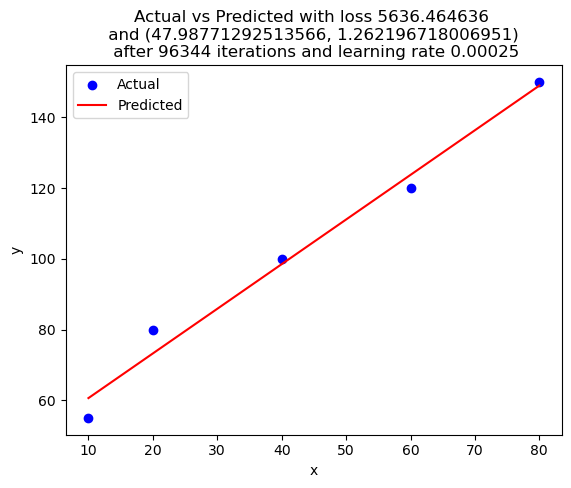

In [4]:
import matplotlib.pyplot as plt

y_pred = [predict(x_i, weight) for x_i in x_train]

plt.scatter(x_train, y_train, color="blue", label="Actual")
plt.plot(x_train, y_pred, color="red", label="Predicted")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Actual vs Predicted with loss {final_loss:.6f} \n and {weight} \n after {time} iterations and learning rate {lr}")
plt.legend()
plt.show()